# Load Lib

In [56]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import optuna
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import GridSearchCV
from src.utils.geo import GEO
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
import joblib
from xgboost import XGBRegressor
from src.utils.loss import rmspe
from src.utils.save import save_model, save_features
import warnings
warnings.filterwarnings('ignore')
from src.models.grnn import GRNN
import optuna
from sklearn.metrics import make_scorer

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.ERROR)

In [58]:
distances = ["euclidean"]
# distances = ["euclidean", "manhattan", "chebyshev", "minkowski", "hamming", "mahalanobis"]

# Load Data

In [59]:
train = pd.read_csv('../data/raw/rossmann/train.csv', low_memory=False)
store = pd.read_csv('../data/raw/rossmann/store.csv', low_memory=False)
test = pd.read_csv('../data/raw/rossmann/test.csv', low_memory=False)
data = pd.merge(train, store, how='left', on='Store')
data['Date'] = pd.to_datetime(data['Date'], errors='coerce')
series = data.sort_values('Date')
series.shape

(1017209, 18)

# 2. EDA

## 2.1 Data Understanding

### 2.1.1 Data Null

pada section ini peneliti akan melakukan pengecekan data apa aja yg null dan menghitung jumlahnya.

In [60]:
# pd.DataFrame(series.isna().sum()).T
series.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

dari hasil analisa diatas, berikut detail hasil interpretasinya.
1. CompetitionDistance memiliki 2642 data null
2. CompetitionOpenSinceMonth memiliki 323348 data null
3. CompetitionOpenSinceYear memiliki 323348 data null
4. Promo2SinceWeek memiliki 508031 data null
5. Promo2SinceYear memiliki 508031 data null
6. PromoInterval memiliki 508031 data null

**Strategi Penanganan Nilai Null**
Berdasarkan hasil analisis dan pemahaman terhadap konteks data:
- Kolom Promo2SinceWeek, Promo2SinceYear, dan PromoInterval memiliki nilai null pada toko yang tidak berpartisipasi dalam program Promo2 (Promo2 = 0).
- Karena pada prosess cross-check di section **2.1.2.2** telah dilakukan proses feature engineering dengan membentuk variabel baru IsPromo2Active, yang merepresentasikan kondisi aktif promosi berdasarkan Promo2 dan PromoInterval, maka ketiga kolom tersebut dinilai redundan dan tidak lagi diperlukan pada tahap pemodelan.

### 2.1.2 Promo, Promo2, PromoInterval, Promo2SinceWeek, Promo2SinceYear

pada section ini peneliti melakukan data understanding dengan memfokuskan pada fitur 'Promo', 'Promo2', 'PromoInterval', 'Promo2SinceWeek', dan 'Promo2SinceYear'. tujuan utama dari analisa ini adalah untuk memahami hubungan antara fitur tersebut dengan fitur 'Sales'.

pada section ini, peneliti melakukan perencanaan explorasi data seperti berikut:
1. Memahami lebih dalam terkait fitur 'Promo', 'Promo2', 'PromoInterval', 'Promo2SinceWeek', dan 'Promo2SinceYear'.
2. melakukan cross check apakah benar ketika toko ikut program Promo2, kemudian pada bulan data['Date'] itu termasuk di daftar `PromoInterval` maka promo2 aktif.

#### 2.1.2.1 Store has join promo2

pada section percobaan ini peneliti menyeleksi salah satu store yang mengikuti promo2.

In [61]:
len(series)

1017209

In [62]:
store_id = 1115
store_data = data[data['Store'] == store_id]
display(store_data.sort_values('Date').head(3))

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
1017208,1115,2,2013-01-01,0,0,0,0,a,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"
1016094,1115,3,2013-01-02,3697,305,1,0,0,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"
1014979,1115,4,2013-01-03,4297,300,1,0,0,1,d,c,5350.0,NaN,NaN,1,22.0,2012.0,"Mar,Jun,Sept,Dec"


dari hasil analisa diatas, berikut detail hasil interpretasinya.

**1. Promo2SinceYear & Promo2SinceWeek**

| Kolom             | Nilai    | Arti                                                                            |
| ----------------- | -------- | ------------------------------------------------------------------------------- |
| `Promo2SinceYear` | `2012.0` | Toko ini mulai ikut program Promo2 pada **tahun 2012**                          |
| `Promo2SinceWeek` | `22.0`   | dan mulai berlaku **minggu ke-22 tahun 2012**, yaitu sekitar **akhir Mei 2012** |

➡️ Jadi, sejak akhir Mei 2012, toko #1115 menjadi bagian dari **Promo2**, yaitu *program promosi berulang* yang aktif beberapa kali dalam setahun.

> Walaupun data penjualan di sini adalah Januari 2013 (`Date ≈ 1356998400000` = 1 Jan 2013), berarti toko ini sudah ikut Promo2 selama sekitar **32 minggu** sebelum tanggal itu.

---

**2. Promo2**

| Kolom    | Nilai | Arti                                                    |
| -------- | ----- | ------------------------------------------------------- |
| `Promo2` | `1`   | Toko ini **terdaftar** sebagai peserta *Promo2 program* |

> Artinya: toko ini *eligible* menjalankan promosi berulang (bukan berarti setiap hari sedang ada promo).
> Semua toko dengan `Promo2=1` memiliki jadwal promosi musiman yang dijelaskan oleh `PromoInterval`.

---

**3. PromoInterval**

| Kolom           | Nilai                | Arti                                                                                                           |
| --------------- | -------------------- | -------------------------------------------------------------------------------------------------------------- |
| `PromoInterval` | `"Mar,Jun,Sept,Dec"` | Toko ini mengadakan promosi **empat kali setahun**, yaitu pada **bulan Maret, Juni, September, dan Desember.** |

> Jadi ketika bulan berada di salah satu dari interval ini, toko menjalankan promo aktif dari program Promo2.
> Kalau misalnya tanggal data adalah Januari 2013, berarti toko **tidak sedang dalam masa promo**, meskipun `Promo2=1`.

---

**4. Promo**

| Kolom   | Nilai | Arti                                             |
| ------- | ----- | ------------------------------------------------ |
| `Promo` | `0`   | Tidak ada promosi reguler (Promo1) pada hari itu |

> `Promo` dan `Promo2` berbeda:
>
> * `Promo` adalah promosi **harian / jangka pendek**, bisa aktif kapan saja.
> * `Promo2` adalah program **promo berulang jangka panjang** yang aktif pada bulan-bulan tertentu (`PromoInterval`).

---

**Konteks Ketiga Baris Data**

| Tanggal    | Open | Sales | Promo | Promo2 | Bulan | Apakah Sedang Promo2?                           |
| ---------- | ---- | ----- | ----- | ------ | ----- | ----------------------------------------------- |
| 2013-01-01 | 0    | 0     | 0     | 1      | Jan   | ❌ Tidak (Jan tidak termasuk “Mar,Jun,Sept,Dec”) |
| 2013-01-02 | 1    | 3697  | 0     | 1      | Jan   | ❌ Tidak                                         |
| 2013-01-03 | 1    | 4297  | 0     | 1      | Jan   | ❌ Tidak                                         |

➡️ Jadi, meskipun `Promo2=1` (toko ikut program Promo2), toko **tidak sedang menjalankan promosi aktif** pada periode data ini, karena bulan Januari **tidak termasuk** di daftar interval promosi (`Mar,Jun,Sept,Dec`).

---

**Kesimpulan visual (ringkas):**

| Fitur                                 | Level          | Arti praktis                       |
| ------------------------------------- | -------------- | ---------------------------------- |
| `Promo`                               | harian         | promosi aktif hari itu (0 = tidak) |
| `Promo2`                              | jangka panjang | toko ikut program promo berulang   |
| `Promo2SinceYear` / `Promo2SinceWeek` | historis       | kapan toko mulai ikut program      |
| `PromoInterval`                       | jadwal         | bulan-bulan promo berulang aktif   |


#### 2.1.2.2 Cross check apakah benar ketika toko ikut program Promo2, dan pada bulan data['Date'] itu termasuk di daftar `PromoInterval` maka label `IsPromo2Active=1`?

In [63]:
series_copy = series.copy()
series_copy['MonthStr'] = series_copy['Date'].dt.strftime('%b')  # Contoh: 'Jan', 'Feb', ...

# Buat kolom IsPromo2Active
def is_promo2_active(row):
    if row['Promo2'] == 1 and isinstance(row['PromoInterval'], str):
        # Cek apakah bulan saat ini ada di daftar PromoInterval
        return 1 if row['MonthStr'] in row['PromoInterval'].split(',') else 0
    else:
        return 0

series_copy['IsPromo2Active'] = series_copy.apply(is_promo2_active, axis=1)

# Tampilkan beberapa kolom relevan untuk cross-check
display(
    series_copy[
        [
            'Store', 'Date', 'Promo', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear',
            'PromoInterval', 'MonthStr', 'IsPromo2Active'
        ]
    ].head(10)
)

,Store,Date,Promo,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,MonthStr,IsPromo2Active
1017208,1115,2013-01-01,0,1,22.0,2012.0,"Mar,Jun,Sept,Dec",Jan,0
1016473,379,2013-01-01,0,0,NaN,NaN,NaN,Jan,0
1016472,378,2013-01-01,0,0,NaN,NaN,NaN,Jan,0
1016471,377,2013-01-01,0,1,18.0,2010.0,"Feb,May,Aug,Nov",Jan,0
1016470,376,2013-01-01,0,0,NaN,NaN,NaN,Jan,0
1016469,375,2013-01-01,0,1,37.0,2009.0,"Jan,Apr,Jul,Oct",Jan,1
1016468,374,2013-01-01,0,0,NaN,NaN,NaN,Jan,0
1016467,373,2013-01-01,0,1,22.0,2012.0,"Jan,Apr,Jul,Oct",Jan,1
1016466,372,2013-01-01,0,1,18.0,2014.0,"Jan,Apr,Jul,Oct",Jan,1
1016465,371,2013-01-01,0,1,45.0,2014.0,"Feb,May,Aug,Nov",Jan,0


dari hasil interpretasi diatas, bisa di simpulkan sebagai berikut:
1. Ketika toko ikut program Promo2, dan pada bulan data['Date'] itu termasuk di daftar `PromoInterval`, maka label `IsPromo2Active=1`.
2. Ketika toko tidak ikut program Promo2, atau `PromoInterval` kosong (tidak ada), maka label `IsPromo2Active=0`.
3. Kolom [PromoInterval, MonthStr, Promo2SinceWeek, Promo2SinceYear] seharusnya tidak berguna lagi setelah kita membuat kolom IsPromo2Active.

### 2.1.3 Analisa korelasi

In [64]:
corr_matrix = series.corr(numeric_only=True)

# ambil hanya korelasi dengan kolom 'Sales'
corr_sales = corr_matrix['Sales']

# filter nilai negatif saja
corr_negative = corr_sales[corr_sales < 0].sort_values()

display(corr_negative)

plt.figure(figsize=(14, 10), dpi=800)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5
)
plt.title("Heatmap Korelasi Fitur Dataset Rossmann Store Sales", fontsize=14, pad=16)
plt.tight_layout()
plt.show()

DayOfWeek                   -0.462125
Promo2                      -0.091040
CompetitionOpenSinceMonth   -0.028257
Promo2SinceYear             -0.021127
CompetitionDistance         -0.019229
Name: Sales, dtype: float64

#### 2.1.3.1 Korelasi subset Promo2 = 1

`Promo2SinceWeek` dan `Promo2SinceYear` hanya terisi jika toko ikut program Promo2 (`Promo2 = 1`). Pada heatmap sebelumnya, korelasi `Promo2` dengan kedua kolom tersebut menjadi **NaN** (cell blank) karena setelah drop null, `Promo2` konstan (= 1).

Analisa berikut memakai subset `Promo2 == 1` dan mengecualikan kolom `Promo2` agar heatmap menampilkan korelasi yang terdefinisi.

Baris subset Promo2=1: 509,178


Store                             0
DayOfWeek                         0
Sales                             0
Customers                         0
Open                              0
Promo                             0
Promo2SinceWeek                   0
Promo2SinceYear                   0
SchoolHoliday                     0
CompetitionDistance             758
CompetitionOpenSinceMonth    184852
CompetitionOpenSinceYear     184852
dtype: int64

DayOfWeek                   -0.480160
CompetitionOpenSinceMonth   -0.043128
Promo2SinceYear             -0.021127
Store                       -0.011230
CompetitionOpenSinceYear    -0.010562
Name: Sales, dtype: float64

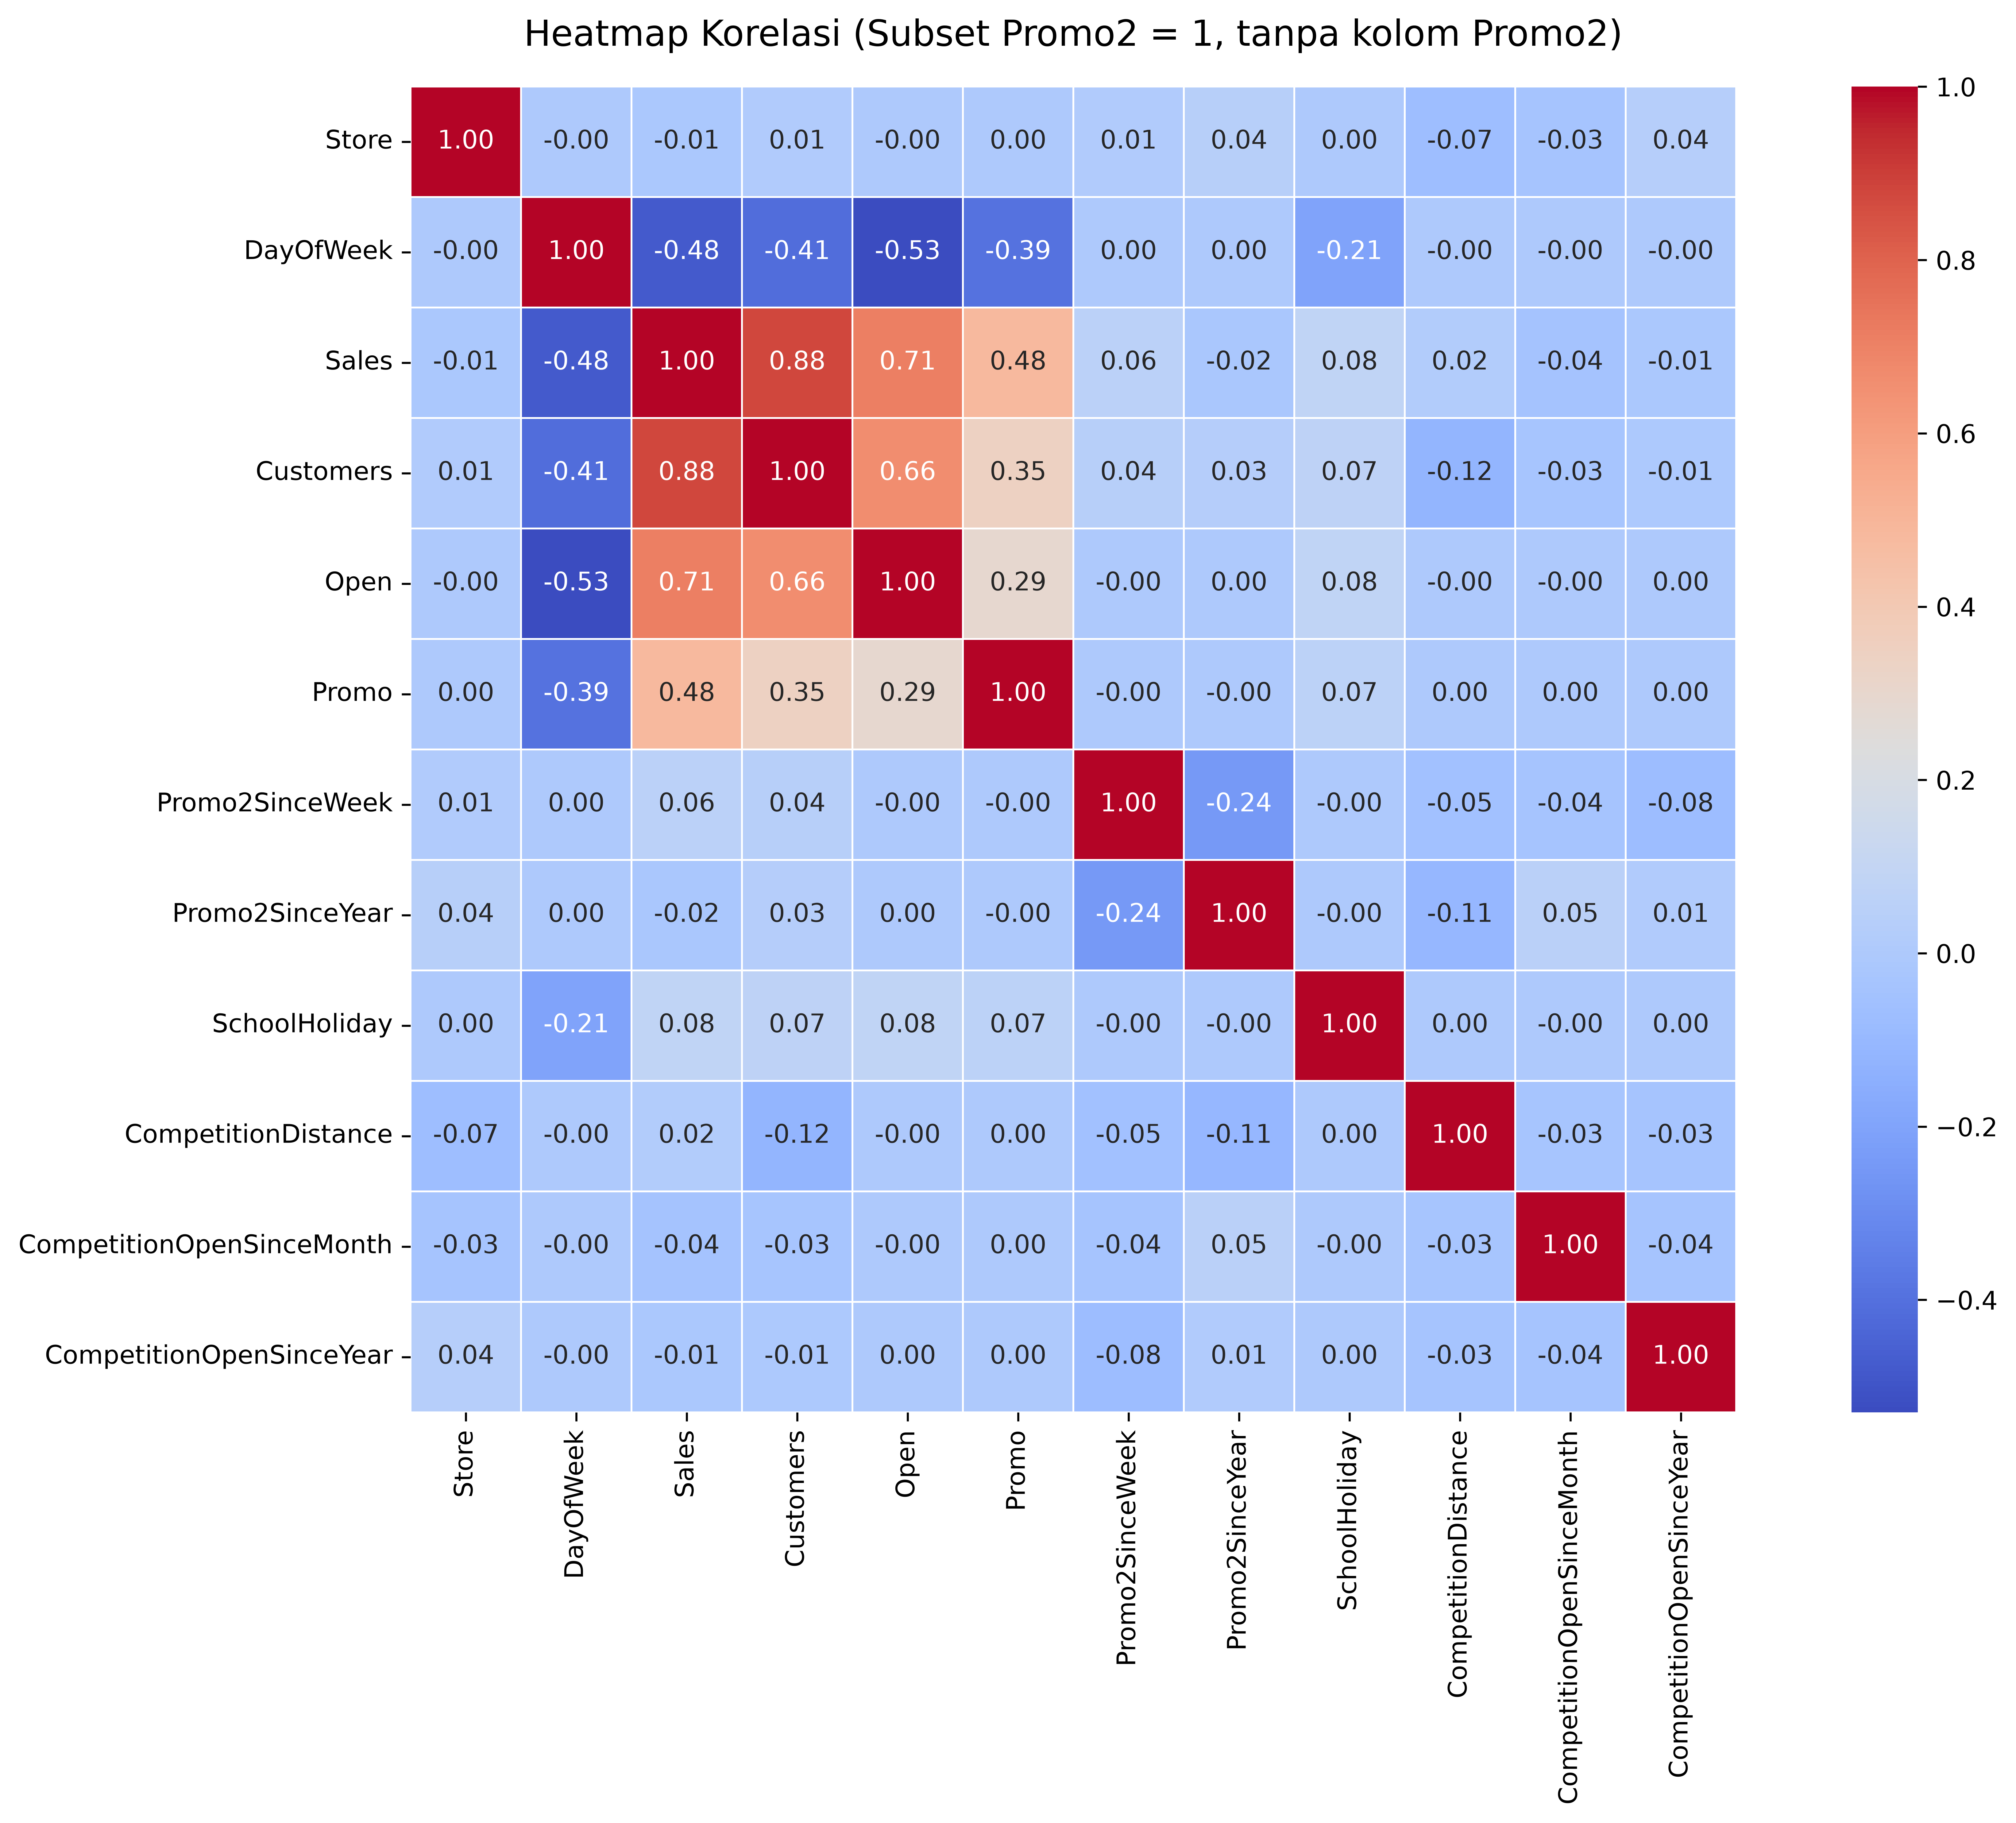

In [65]:
promo2_cols = [
    "Store", "DayOfWeek", "Sales", "Customers", "Open", "Promo",
    "Promo2SinceWeek", "Promo2SinceYear",
    "SchoolHoliday", "CompetitionDistance",
    "CompetitionOpenSinceMonth", "CompetitionOpenSinceYear",
]

series_promo2 = series.loc[series["Promo2"] == 1, promo2_cols].copy()

print(f"Baris subset Promo2=1: {len(series_promo2):,}")
display(series_promo2.isna().sum())

corr_promo2 = series_promo2.corr(numeric_only=True)

corr_sales_promo2 = corr_promo2["Sales"]
corr_negative_promo2 = corr_sales_promo2[corr_sales_promo2 < 0].sort_values()
display(corr_negative_promo2)

plt.figure(figsize=(14, 10), dpi=600)
sns.heatmap(
    corr_promo2,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5,
)
plt.title(
    "Heatmap Korelasi (Subset Promo2 = 1, tanpa kolom Promo2)",
    fontsize=14,
    pad=16,
)
plt.tight_layout()
plt.show()

### 2.1.4 Count store

In [66]:
print(f"Count stores: {series['Store'].nunique()}")

Count stores: 1115


# Feature Engineering and Data Cleaning

## Feature Engineering

### Create kolom IsPromo2Active

kolom IsPromo2Active akan di buat ketika toko ikut program Promo2, dan pada bulan data['Date'] itu termasuk di daftar `PromoInterval`

In [67]:
series['MonthStr'] = series['Date'].dt.strftime('%b')  # Contoh: 'Jan', 'Feb', ...

def is_promo2_active(row):
    if row['Promo2'] == 1 and isinstance(row['PromoInterval'], str):
        return 1 if row['MonthStr'] in row['PromoInterval'].split(',') else 0
    else:
        return 0

series['IsPromo2Active'] = series.apply(is_promo2_active, axis=1)

### Create feature Promo2DurationWeeks

Buat feature Promo2DurationWeeks dari Promo2SinceWeek dan Promo2SinceYear


In [68]:
series['Promo2DurationWeeks'] = np.where(
    series['Promo2'] == 1,
    (series['Date'].dt.year - series['Promo2SinceYear']) * 52 +
    (series['Date'].dt.isocalendar().week - series['Promo2SinceWeek']),
    0
)
series['Promo2DurationWeeks'] = series['Promo2DurationWeeks'].clip(lower=0).fillna(0)

### One-hot encoding

In [69]:
cat_cols = [
    'StoreType', 
    'Assortment', 
    'StateHoliday',
]
series = pd.get_dummies(series, columns=cat_cols, drop_first=True)
boolean_cols = series.select_dtypes(include='bool').columns
series[boolean_cols] = series[boolean_cols].astype(int)
series.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,IsPromo2Active,Promo2DurationWeeks,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,StateHoliday_c
1017208,1115,2,2013-01-01,0,0,0,0,1,5350.0,NaN,...,0,31.0,0,0,1,0,1,1,0,0
1016473,379,2,2013-01-01,0,0,0,0,1,6630.0,NaN,...,0,0.0,0,0,1,0,0,1,0,0
1016472,378,2,2013-01-01,0,0,0,0,1,2140.0,8.0,...,0,0.0,0,0,0,0,1,1,0,0
1016471,377,2,2013-01-01,0,0,0,0,1,100.0,6.0,...,0,139.0,0,0,0,0,1,1,0,0
1016470,376,2,2013-01-01,0,0,0,0,1,160.0,8.0,...,0,0.0,0,0,0,0,0,1,0,0


### Sort columns

Kolom perlu diurutkan supaya ketika model scaller di export ke file dan load kembali di notebook selanjutnya dia tidak terjadi error karena perbedaan bentuk data yang di transform.

In [70]:
# Pastikan kolom target 'Sales' di paling kanan
target_col = 'Sales'
cols = sorted([c for c in series.columns if c != target_col]) + [target_col]
series = series[cols]
series.columns

Index(['Assortment_b', 'Assortment_c', 'CompetitionDistance',
       'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Customers',
       'Date', 'DayOfWeek', 'IsPromo2Active', 'MonthStr', 'Open', 'Promo',
       'Promo2', 'Promo2DurationWeeks', 'Promo2SinceWeek', 'Promo2SinceYear',
       'PromoInterval', 'SchoolHoliday', 'StateHoliday_a', 'StateHoliday_b',
       'StateHoliday_c', 'Store', 'StoreType_b', 'StoreType_c', 'StoreType_d',
       'Sales'],
      dtype='object')

## Drop null and unnecessary columns

1. Kolom Date di drop karena tidak di perlukan dalam proses prediksi, kolom date hanya di perlukan ketika proses visualisasi hasil prediksi.
2. Kolom CompetitionDistance, CompetitionOpenSinceMonth, CompetitionOpenSinceYear di drop karena terdapat data null dan setelah dilakukan analisa korelasi, nilainya negative dengan Sales.
3. Kolom Promo2SinceWeek, Promo2SinceYear, PromoInterval, MonthStr di drop karena tidak berguna lagi setelah membuat kolom IsPromo2Active.

In [71]:
print("Sebelum di-drop:", series.shape)

series.drop(columns=[
    # 'CompetitionDistance', 
    # 'CompetitionOpenSinceMonth', 
    # 'CompetitionOpenSinceYear', 
    
    'Promo2SinceWeek', 
    'Promo2SinceYear', 
    'PromoInterval',
    'MonthStr',
    # 'Date',
    ], inplace=True, errors='ignore')
series.dropna(inplace=True)
print("Sesudah di-drop:", series.shape)

Sebelum di-drop: (1017209, 26)
Sesudah di-drop: (693861, 22)


# Model Training

## XGBoost

### Training

In [72]:
# ==========================
# 4. Split data train-test
# ==========================
total_data = len(series)
train_size = int(total_data * 0.8)
test_size = total_data - train_size

train = series[:train_size]
test  = series[train_size:]

X_train = train.drop(columns=['Sales', 'Date'])
y_train = train['Sales']
X_test  = test.drop(columns=['Sales', 'Date'])
y_test  = test['Sales']

# ==========================
# 5. Scaling
# ==========================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ==========================
# 6. Grid Search XGBoost
# ==========================
param_grid = {
    'n_estimators': [100, 900],
    'learning_rate': [0.2, 0.3, 0.4],
    'max_depth': [6, 9, 12],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8, 2.0],
    'booster': ['gbtree'],
    'max_bin': [256]
}

tscv = TimeSeriesSplit(n_splits=3)

xgb = XGBRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
best_params = grid_search.best_params_
 
print("Best RMSE:", -grid_search.best_score_)
print("Best Params:", grid_search.best_params_)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best RMSE: 551.5037638346354
Best Params: {'booster': 'gbtree', 'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_bin': 256, 'max_depth': 6, 'n_estimators': 900, 'subsample': 0.8}


### Testing

In [73]:
xgb_model = XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=best_params['n_estimators'], 
    max_depth=best_params['max_depth'],
    learning_rate=best_params['learning_rate'],
    # subsample=best_params['subsample'],
    # colsample_bytree=best_params['colsample_bytree'],
)

xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test_scaled)

# hitung RMSE
mse = mean_squared_error(y_test, xgb_predictions)
rmse = np.sqrt(mse)

print("RMSE:", rmse)
print("MSE:", mse)

RMSE: 6243.8254299748005
MSE: 38985356.0


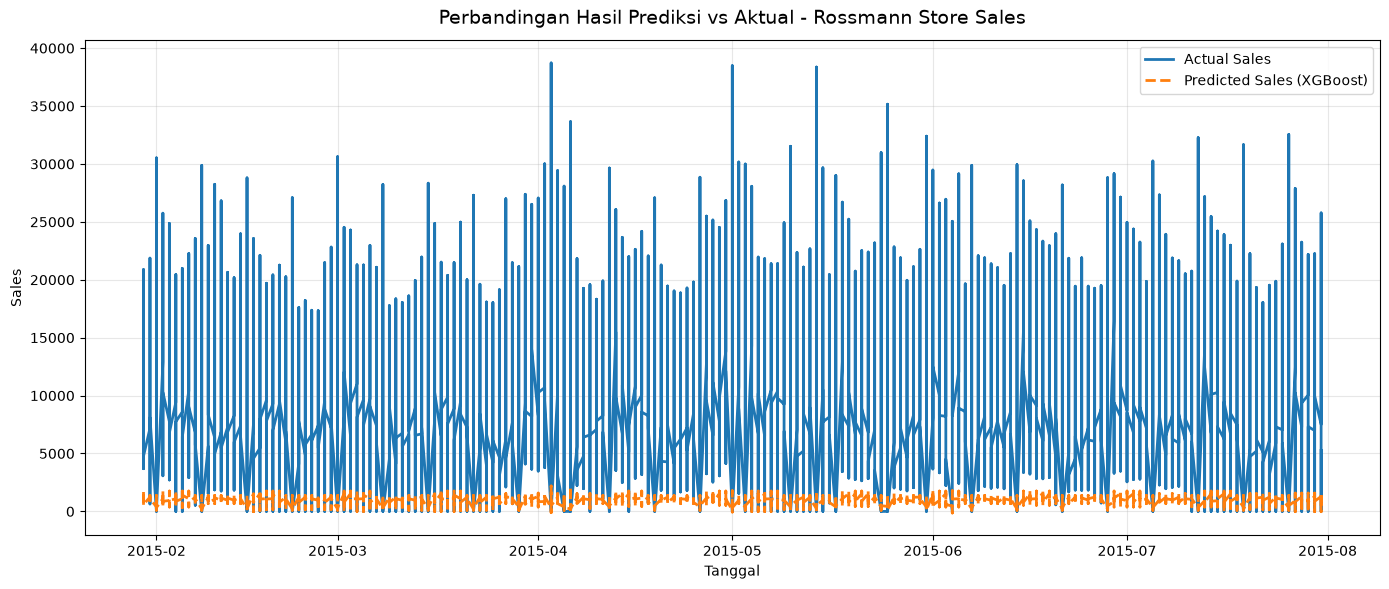

In [74]:
dates = data.loc[test.index, 'Date']

results = pd.DataFrame({
    'Date': dates,
    'Actual_Sales': y_test.values,
    'Predicted_Sales': xgb_predictions
})

plt.figure(figsize=(14, 6))
plt.plot(results['Date'], results['Actual_Sales'], label='Actual Sales', linewidth=2)
plt.plot(results['Date'], results['Predicted_Sales'], label='Predicted Sales (XGBoost)', linestyle='--', linewidth=2)

plt.title('Perbandingan Hasil Prediksi vs Aktual - Rossmann Store Sales', fontsize=14, pad=12)
plt.xlabel('Tanggal')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## XGBoost with Sales has logarithmic transformation

In [75]:
# ===============================================================
# 1. FEATURE ENGINEERING: LOG TRANSFORMATION
# ===============================================================
data_to_transform = series.copy()

log_cols = ["Sales"]

for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

# Gunakan versi log sebagai fitur & target
data_to_train = data_to_transform.copy()
data_to_train.drop(columns=log_cols, inplace=True)

TARGET = "Sales_log"

# ===============================================================
# 2. SPLIT DATA TRAIN-TEST
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=["Sales_log", "Date"])
y_train = train[TARGET]
X_test = test.drop(columns=["Sales_log", "Date"])
y_test = test[TARGET]

# ===============================================================
# 3. SCALING
# ===============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# ===============================================================
# 5. GRID SEARCH XGBOOST (TRAIN DI RESIDUAL)
# ===============================================================
param_grid = {
    'n_estimators': [100, 900],
    'learning_rate': [0.2, 0.3, 0.4],
    'max_depth': [6, 9, 12],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8, 2.0],
    'booster': ['gbtree'],
    'max_bin': [256]
}

tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)
best_params = grid_search.best_params_
print("Best Params (XGB):", best_params)

xgb_best = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    **best_params,
)

xgb_best.fit(X_train_scaled, y_train)

# ===============================================================
# 6. XGBOOST PREDICTION
# ===============================================================
xgb_pred_log = xgb_best.predict(X_test_scaled)
# ===============================================================
# 7A. EVALUATION DI LOG SCALE (TANPA DI-REVERSE)
# ===============================================================

# Prediksi LR & Hybrid dalam skala LOG
mse_hybrid_log = mean_squared_error(y_test, xgb_pred_log)
rmse_hybrid_log = np.sqrt(mse_hybrid_log)

print("=== LOG SCALE (Belum di-Inverse) ===")
print(f"MSE Hybrid (log) : {mse_hybrid_log:.5f}")
print(f"RMSE Hybrid (log): {rmse_hybrid_log:.5f}")
print()


# ===============================================================
# 7B. EVALUATION DI ORIGINAL SCALE (SETELAH INVERSE)
# ===============================================================

# Ubah kembali ke skala asli
y_test_real = np.expm1(y_test)
hybrid_pred_real = np.expm1(xgb_pred_log)

mse_hybrid_real = mean_squared_error(y_test_real, hybrid_pred_real)
rmse_hybrid_real = np.sqrt(mse_hybrid_real)

print("=== ORIGINAL SCALE (Setelah Inverse) ===")
print(f"MSE Hybrid (real) : {mse_hybrid_real:.3f}")
print(f"RMSE Hybrid (real): {rmse_hybrid_real:.3f}")
print()

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Params (XGB): {'booster': 'gbtree', 'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_bin': 256, 'max_depth': 6, 'n_estimators': 900, 'subsample': 0.8}
=== LOG SCALE (Belum di-Inverse) ===
MSE Hybrid (log) : 0.00484
RMSE Hybrid (log): 0.06955

=== ORIGINAL SCALE (Setelah Inverse) ===
MSE Hybrid (real) : 239919.761
RMSE Hybrid (real): 489.816



## LRXGB with Residual Correction

Pada model ini, kita menggunakan kombinasi antara linear regression dan XGBoost dengan penyesuaian residual pada model linear untuk memperbaiki kesalahan prediksi dengan menggunakan XGBoost.

### Training

#### With log transform

##### Analisa Distribusi Data Sales vs Sales Log

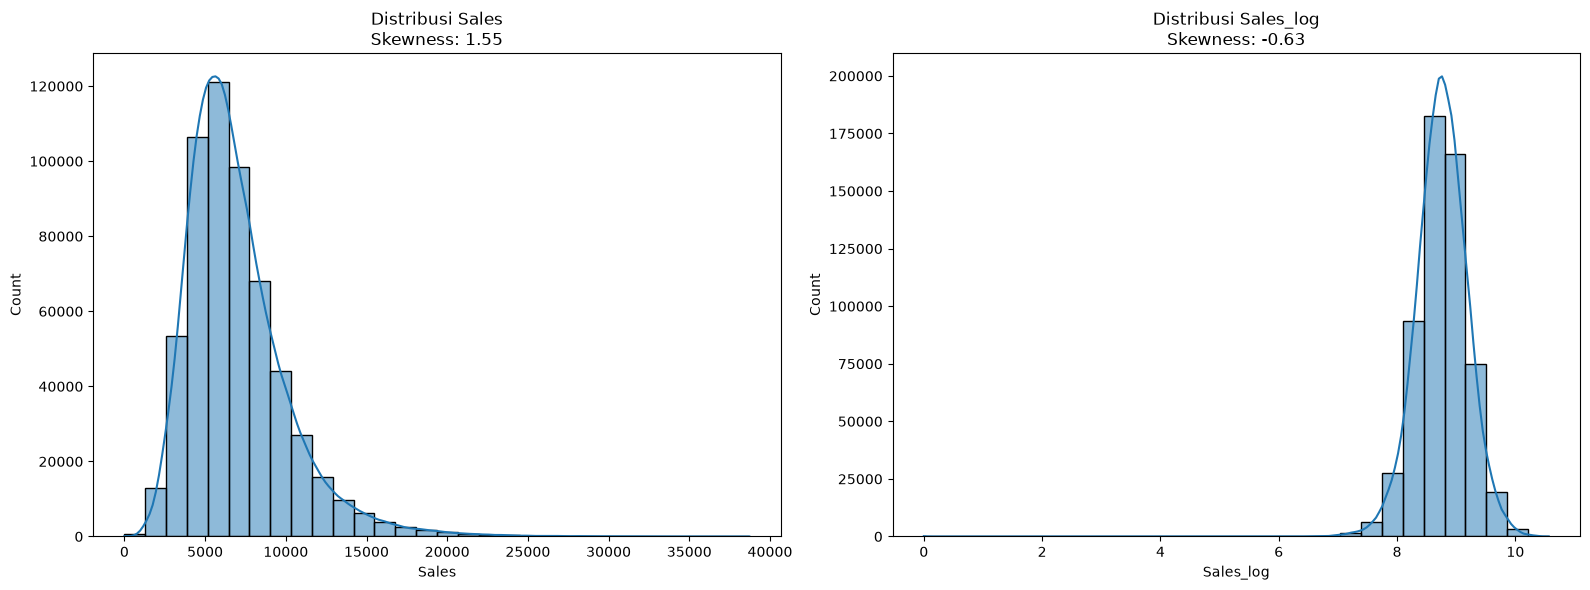

In [76]:
data_to_transform = series[series["Open"] == 1].copy()
log_cols = ["Sales"]

for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

cols_to_plot = ["Sales", "Sales_log"]

plt.figure(figsize=(16, 6))

for i, col in enumerate(cols_to_plot, 1):
    skewness = data_to_transform[col].skew()
    
    plt.subplot(1, 2, i)
    sns.histplot(data_to_transform[col].dropna(), kde=True, bins=30)
    plt.title(f"Distribusi {col}\nSkewness: {skewness:.2f}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

##### Using Logarithmic (RMSE, MSE, R2, MAE)

In [77]:
# ===============================================================
# 1. FEATURE ENGINEERING: LOG TRANSFORMATION
# ===============================================================
data_to_transform = series[series["Sales"] > 0].copy()

log_cols = ["Sales"]
for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

# Gunakan versi log sebagai fitur & target
data_to_train = data_to_transform.copy()
data_to_train.drop(columns=log_cols, inplace=True)

TARGET = "Sales_log"

# ===============================================================
# 2. SPLIT DATA TRAIN-TEST
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=["Sales_log", "Date"])
y_train = train.drop(columns="Date")[TARGET]
X_test = test.drop(columns=["Sales_log", "Date"])
y_test = test.drop(columns="Date")[TARGET]

# ===============================================================
# 4. TRAIN LINEAR REGRESSION (BAGIAN HYBRID)
# ===============================================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred_train = lr_model.predict(X_train)
lr_pred_test = lr_model.predict(X_test)

residual_train = y_train - lr_pred_train

# ===============================================================
# 5. GRID SEARCH XGBOOST (TRAIN DI RESIDUAL)
# ===============================================================
# param_grid = {
#     'n_estimators': [100, 900],
#     'learning_rate': [0.2, 0.3, 0.4],
#     'max_depth': [6, 9, 12],
#     'subsample': [0.8, 2.0],
#     'colsample_bytree': [0.8, 2.0],
#     'booster': ['gbtree'],
#     'max_bin': [256]
# }
param_grid = {
    'n_estimators': [900],
    'learning_rate': [0.2],
    'max_depth': [9],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8],
    'booster': ['gbtree'],
    'max_bin': [256]
}

tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, residual_train)
best_params = grid_search.best_params_
print("Best Params (XGB):", best_params)

xgb_best = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    **best_params,
)

xgb_best.fit(X_train, residual_train)

# ===============================================================
# 6. HYBRID PREDICTION
# ===============================================================
residual_pred_test = xgb_best.predict(X_test)
hybrid_pred_log = lr_pred_test + residual_pred_test

# Convert back to original scale
hybrid_pred = np.expm1(hybrid_pred_log)
sales_actual = np.expm1(y_test)

# ===============================================================
# 7A. EVALUATION DI LOG SCALE (TANPA DI-REVERSE)
# ===============================================================

# Prediksi LR & Hybrid dalam skala LOG
y_test_log = y_test
lr_pred_test_log = lr_pred_test
hybrid_pred_log = lr_pred_test + residual_pred_test

mse_hybrid_log = mean_squared_error(y_test_log, hybrid_pred_log)
rmse_hybrid_log = np.sqrt(mse_hybrid_log)
r2_hybrid_log = r2_score(y_test_log, hybrid_pred_log)
mae_hybrid_log = mean_absolute_error(y_test_log, hybrid_pred_log)


print("=== LOG SCALE (Belum di-Inverse) ===")
print(f"MSE Hybrid (log) : {mse_hybrid_log:.5f}")
print(f"RMSE Hybrid (log): {rmse_hybrid_log:.5f}")
print(f"R2 Hybrid (log): {r2_hybrid_log:.5f}")
print(f"MAE Hybrid (log): {mae_hybrid_log:.5f}")
print()


# ===============================================================
# 7B. EVALUATION DI ORIGINAL SCALE (SETELAH INVERSE)
# ===============================================================

# Ubah kembali ke skala asli
y_test_real = np.expm1(y_test_log)
lr_pred_real = np.expm1(lr_pred_test_log)
hybrid_pred_real = np.expm1(hybrid_pred_log)

mse_hybrid_real = mean_squared_error(y_test_real, hybrid_pred_real)
rmse_hybrid_real = np.sqrt(mse_hybrid_real)
r2_hybrid_real = r2_score(y_test_real, hybrid_pred_real)
mae_hybrid_real = mean_absolute_error(y_test_real, hybrid_pred_real)

print("=== ORIGINAL SCALE (Setelah Inverse) ===")
print(f"MSE Hybrid (real) : {mse_hybrid_real:.3f}")
print(f"RMSE Hybrid (real): {rmse_hybrid_real:.3f}")
print(f"R2 Hybrid (real): {r2_hybrid_real:.5f}")
print(f"MAE Hybrid (real): {mae_hybrid_real:.5f}")
print()

Fitting 3 folds for each of 2 candidates, totalling 6 fits
Best Params (XGB): {'booster': 'gbtree', 'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_bin': 256, 'max_depth': 9, 'n_estimators': 900, 'subsample': 0.8}
=== LOG SCALE (Belum di-Inverse) ===
MSE Hybrid (log) : 0.00493
RMSE Hybrid (log): 0.07022
R2 Hybrid (log): 0.97238
MAE Hybrid (log): 0.05373

=== ORIGINAL SCALE (Setelah Inverse) ===
MSE Hybrid (real) : 333659.508
RMSE Hybrid (real): 577.633
R2 Hybrid (real): 0.96512
MAE Hybrid (real): 376.11604



In [78]:
# joblib.dump(lr_model, './models/v1.5/lr_model.pkl')
# joblib.dump(xgb_best, './models/v1.5/xgb_model.pkl')
# joblib.dump(series.columns, './models/v1.5/features.pkl')

# print("✅ Model dan scaler berhasil disimpan di folder 'models/'")

##### Using Logarithmic (RMSPE)

In [79]:
# ===============================================================
# 1. FEATURE ENGINEERING: LOG TRANSFORMATION
# ===============================================================
data_to_transform = series[(series["Sales"] > 0)].copy()

log_cols = ["Sales"]

for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

# Gunakan versi log sebagai fitur & target
data_to_train = data_to_transform.copy()
data_to_train.drop(columns=log_cols, inplace=True)

TARGET = "Sales_log"

# ===============================================================
# 2. SPLIT DATA TRAIN-TEST
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=["Sales_log", "Date"])
y_train = train.drop(columns="Date")[TARGET]
X_test = test.drop(columns=["Sales_log", "Date"])
y_test = test.drop(columns="Date")[TARGET]

# ===============================================================
# 4. TRAIN LINEAR REGRESSION (BAGIAN HYBRID)
# ===============================================================
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred_train = lr_model.predict(X_train)
lr_pred_test = lr_model.predict(X_test)

residual_train = y_train - lr_pred_train

# ===============================================================
# 5. GRID SEARCH XGBOOST (TRAIN DI RESIDUAL)
# ===============================================================
param_grid = {
    'n_estimators': [100, 900],
    'learning_rate': [0.2, 0.3, 0.4],
    'max_depth': [6, 9, 12],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8, 2.0],
    'booster': ['gbtree'],
    'max_bin': [256]
}

tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, residual_train)
best_params = grid_search.best_params_
print("Best Params (XGB):", best_params)

xgb_best = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    **best_params,
)

xgb_best.fit(X_train, residual_train)

# ===============================================================
# 6. HYBRID PREDICTION
# ===============================================================
residual_pred_test = xgb_best.predict(X_test)
hybrid_pred_log = lr_pred_test + residual_pred_test

# Convert back to original scale
hybrid_pred = np.expm1(hybrid_pred_log)
sales_actual = np.expm1(y_test)

# ===============================================================
# 7A. EVALUATION DI LOG SCALE (TANPA DI-REVERSE)
# ===============================================================

# Prediksi LR & Hybrid dalam skala LOG
y_test_log = y_test
lr_pred_test_log = lr_pred_test
hybrid_pred_log = lr_pred_test + residual_pred_test

rmspe_hybrid_log = rmspe(y_test_log, hybrid_pred_log)


print("=== LOG SCALE (Belum di-Inverse) ===")
print(f"RMSPE Hybrid (log): {rmspe_hybrid_log:.5f}")
print()


# ===============================================================
# 7B. EVALUATION DI ORIGINAL SCALE (SETELAH INVERSE)
# ===============================================================

# Ubah kembali ke skala asli
y_test_real = np.expm1(y_test_log)
lr_pred_real = np.expm1(lr_pred_test_log)
hybrid_pred_real = np.expm1(hybrid_pred_log)

mse_hybrid_real = mean_squared_error(y_test_real, hybrid_pred_real)
rmse_hybrid_real = np.sqrt(mse_hybrid_real)
rmspe_hybrid_real = rmspe(y_test_real, hybrid_pred_real)
r2_hybrid_real = r2_score(y_test_real, hybrid_pred_real)
mae_hybrid_real = mean_absolute_error(y_test_real, hybrid_pred_real)

print("=== ORIGINAL SCALE (Setelah Inverse) ===")
print(f"RMSPE Hybrid (real): {rmspe_hybrid_real:.5f}")
print()

Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Params (XGB): {'booster': 'gbtree', 'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_bin': 256, 'max_depth': 6, 'n_estimators': 900, 'subsample': 0.8}
=== LOG SCALE (Belum di-Inverse) ===
RMSPE Hybrid (log): 0.00800

=== ORIGINAL SCALE (Setelah Inverse) ===
RMSPE Hybrid (real): 0.06779



In [80]:
# # uncomment if needed
# version_tag = "1.4"
# features_used = list(X_train.columns)

# save_model(scaler, "scaler", version_tag)
# save_model(lr_model, "lr_model", version_tag)
# save_model(xgb_best, "xgb_model", version_tag)
# save_features(features_used, version_tag)

##### Using Box-Cox

In [ ]:
# ===============================================================
# A. FEATURE ENGINEERING: BOX-COX TRANSFORMATION
# ===============================================================
from scipy.stats import boxcox

data_bc = series[(series["Open"] == 1) & (series["Sales"] > 0)].copy()

# Transformasi Box-Cox
sales_bc, lambda_bc = boxcox(data_bc["Sales"])

data_bc["Sales_boxcox"] = sales_bc

print("Lambda Box-Cox:", lambda_bc)

# Gunakan Box-Cox sebagai target
data_to_train = data_bc.copy()
data_to_train.drop(columns=["Sales"], inplace=True)

TARGET = "Sales_boxcox"

# ===============================================================
# SPLIT DATA TRAIN-TEST
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=[TARGET, 'Date'])
y_train = train[TARGET]
X_test = test.drop(columns=[TARGET, 'Date'])
y_test = test[TARGET]

# ===============================================================
# SCALING
# ===============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================================================
# LINEAR REGRESSION (HYBRID STEP)
# ===============================================================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

lr_pred_train = lr_model.predict(X_train_scaled)
lr_pred_test = lr_model.predict(X_test_scaled)

residual_train = y_train - lr_pred_train

# ===============================================================
# GRID SEARCH XGBOOST (RESIDUAL MODEL)
# ===============================================================
tscv = TimeSeriesSplit(n_splits=5)
xgb = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist"
)

param_grid = {
    'n_estimators': [100, 900],
    'learning_rate': [0.2, 0.3, 0.4],
    'max_depth': [6, 9, 12],
    'subsample': [0.8, 2.0],
    'colsample_bytree': [0.8, 2.0],
    'booster': ['gbtree'],
    'max_bin': [256]
}

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, residual_train)
best_params = grid_search.best_params_
print("Best Params (XGB - BoxCox):", best_params)

xgb_bc = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    **best_params
)
xgb_bc.fit(X_train_scaled, residual_train)

# ===============================================================
# HYBRID PREDICTION (BOX-COX SCALE)
# ===============================================================
residual_pred_test = xgb_bc.predict(X_test_scaled)
hybrid_pred_bc = lr_pred_test + residual_pred_test

# ===============================================================
# 7A. EVALUATION DI BOXCOX SCALE (BELUM DI-INVERSE)
# ===============================================================

y_test_bc = y_test  # tetap dalam skala BoxCox
lr_pred_bc = lr_pred_test
hybrid_pred_bc_scale = hybrid_pred_bc  # hybrid dalam skala BoxCox

mse_lr_bc = mean_squared_error(y_test_bc, lr_pred_bc)
mse_hybrid_bc = mean_squared_error(y_test_bc, hybrid_pred_bc_scale)

rmse_lr_bc = np.sqrt(mse_lr_bc)
rmse_hybrid_bc = np.sqrt(mse_hybrid_bc)

print("=== BOX-COX SCALE (Belum di-Inverse) ===")
print(f"MSE LR (BoxCox)     : {mse_lr_bc:.5f}")
print(f"MSE Hybrid (BoxCox) : {mse_hybrid_bc:.5f}")
print(f"RMSE LR (BoxCox)    : {rmse_lr_bc:.5f}")
print(f"RMSE Hybrid (BoxCox): {rmse_hybrid_bc:.5f}")
print()

# ===============================================================
# 7B. EVALUATION DI ORIGINAL SCALE (SETELAH INVERSE)
# ===============================================================

def inv_boxcox(y, lam):
    if lam == 0:
        return np.exp(y)
    return np.exp(np.log(lam * y + 1) / lam)

y_test_real = inv_boxcox(y_test.values, lambda_bc)
lr_pred_real = inv_boxcox(lr_pred_test, lambda_bc)
hybrid_pred_real = inv_boxcox(hybrid_pred_bc, lambda_bc)

mse_lr_real = mean_squared_error(y_test_real, lr_pred_real)
mse_hybrid_real = mean_squared_error(y_test_real, hybrid_pred_real)

rmse_lr_real = np.sqrt(mse_lr_real)
rmse_hybrid_real = np.sqrt(mse_hybrid_real)

print("=== ORIGINAL SCALE (Setelah Inverse BoxCox) ===")
print(f"MSE LR (real)     : {mse_lr_real:.3f}")
print(f"MSE Hybrid (real) : {mse_hybrid_real:.3f}")
print(f"RMSE LR (real)    : {rmse_lr_real:.3f}")
print(f"RMSE Hybrid (real): {rmse_hybrid_real:.3f}")
print()


Lambda Box-Cox: 0.09997258365289693


DTypePromotionError: The DType <class 'numpy.dtypes.DateTime64DType'> could not be promoted by <class 'numpy.dtypes.Float64DType'>. This means that no common DType exists for the given inputs. For example they cannot be stored in a single array unless the dtype is `object`. The full list of DTypes is: (<class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.DateTime64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Float64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>, <class 'numpy.dtypes.Int64DType'>)

#### Without log transform

##### Training & Testing

In [ ]:
data_to_train = series.copy()

# ===============================================================
# 3. SPLIT DATA TRAIN-TEST
# ===============================================================
total_data = len(series)
train_size = int(total_data * 0.8)

train = series[:train_size]
test = series[train_size:]

X_train = train.drop(columns=['Sales', 'Date'])
y_train = train['Sales']
X_test  = test.drop(columns=['Sales', 'Date'])
y_test  = test['Sales']

# ===============================================================
# 4. SCALING
# ===============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ===============================================================
# 5. TRAIN LINEAR REGRESSION
# ===============================================================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Prediksi dan residual
lr_pred_train = lr_model.predict(X_train_scaled)
lr_pred_test = lr_model.predict(X_test_scaled)
residual_train = y_train - lr_pred_train  # error pada data train

# ===============================================================
# 6. GRID SEARCH UNTUK XGBOOST (TRAIN DI RESIDUAL)
# ===============================================================
param_grid = {
    'n_estimators': [500],
    'learning_rate': [0.1],
    'max_depth': [7],
    'subsample': [0.6],
    'colsample_bytree': [1.0]
}
# param_grid = {
#     'n_estimators': [900, 1100],
#     'learning_rate': [0.2, 0.4],
#     'max_depth': [9, 12],
#     'subsample': [0.8, 2.0],
#     'colsample_bytree': [0.8, 2.0]
# }


tscv = TimeSeriesSplit(n_splits=3)
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, residual_train)
best_params = grid_search.best_params_
print("Best Params (XGB):", best_params)

# Latih ulang dengan parameter terbaik
xgb_best = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)
xgb_best.fit(X_train_scaled, residual_train)

# ===============================================================
# 7. HYBRID PREDICTION
# ===============================================================
residual_pred_test = xgb_best.predict(X_test_scaled)
hybrid_pred = lr_pred_test + residual_pred_test

# ===============================================================
# 8. EVALUATION
# ===============================================================
mse_lr = mean_squared_error(y_test, lr_pred_test)
mse_xgb = mean_squared_error(y_test, hybrid_pred)
rmse_lr = np.sqrt(mse_lr)
rmse_xgb = np.sqrt(mse_xgb)
r2_lr = r2_score(y_test, lr_pred_test)
r2_xgb = r2_score(y_test, hybrid_pred)
rmspe_hybrid = rmspe(y_test, hybrid_pred)

# print(f"RMSE LR     : {rmse_lr:.3f}")
print(f"RMSE Hybrid : {rmse_xgb:.3f}")
# print(f"RMSPE Hybrid : {rmspe_hybrid:.3f}")
# print(f"R² LR       : {r2_lr:.4f}")
print(f"R² Hybrid   : {r2_xgb:.4f}")

# ===============================================================
# 9. VISUALISASI
# ===============================================================
# plt.figure(figsize=(14,6))
# plt.plot(y_test.values, label='Actual Sales', linewidth=2)
# plt.plot(hybrid_pred, label='Hybrid (LR + XGBoost)', linestyle='--', linewidth=2)
# plt.plot(lr_pred_test, label='Linear Regression', linestyle=':', linewidth=1.5)
# plt.title('Hybrid Model (Linear Regression + XGBoost Residual Correction)')
# plt.xlabel('Time Index')
# plt.ylabel('Sales')
# plt.legend()
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Best Params (XGB): {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.6}
RMSE Hybrid : 661.599
R² Hybrid   : 0.9707


##### Visulisasi

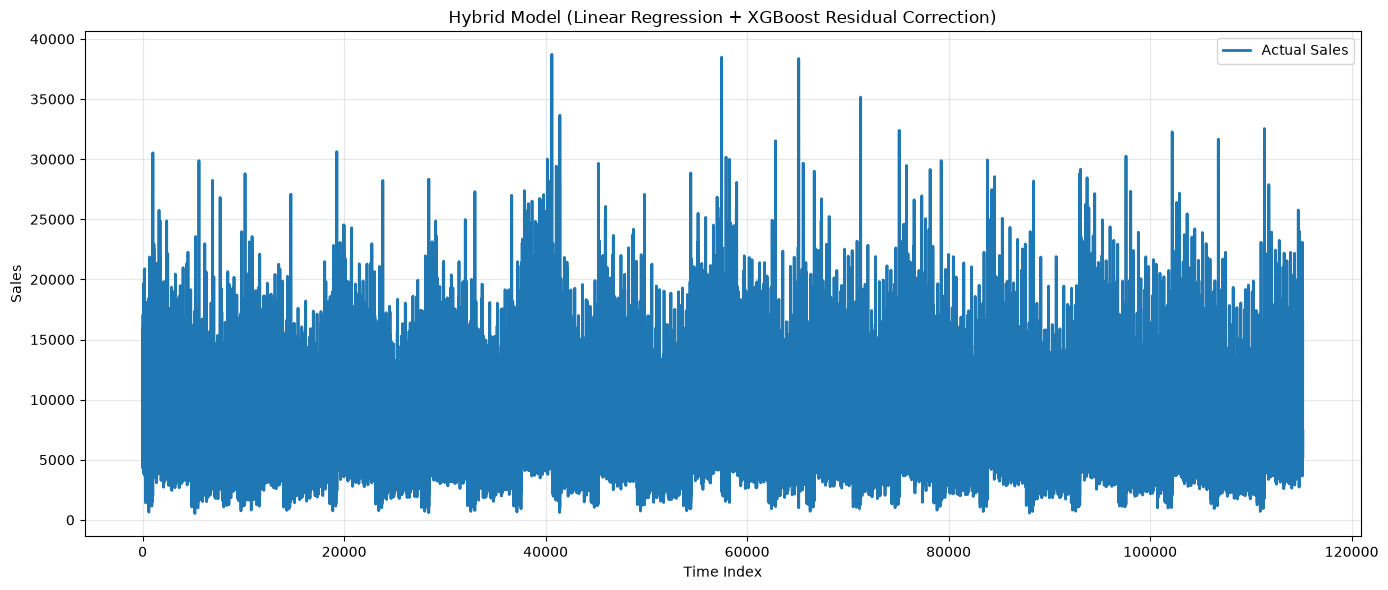

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(y_test.values, label='Actual Sales', linewidth=2)
plt.plot(hybrid_pred, label='Hybrid (LR + XGBoost)', linestyle='--', linewidth=2)
plt.plot(lr_pred_test, label='Linear Regression', linestyle=':', linewidth=1.5)
plt.title('Hybrid Model (Linear Regression + XGBoost Residual Correction)')
plt.xlabel('Time Index')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Save Model

In [ ]:
# joblib.dump(scaler, 'models/scaler.best.pkl')
# joblib.dump(lr_model, 'models/lr_model.best.pkl')
# joblib.dump(xgb_best, 'models/xgb_model.best.pkl')

# print("✅ Model dan scaler berhasil disimpan di folder 'models/'")

✅ Model dan scaler berhasil disimpan di folder 'models/'


### Testing & Visualisasi (transformed sales)

#### Testing

In [ ]:
version = 'v1.3'
scaler = joblib.load(f"./models/{version}/scaler.pkl")
lr_model = joblib.load(f"./models/{version}/lr_model.pkl")
xgb_model = joblib.load(f"./models/{version}/xgb_model.pkl")
features = joblib.load(f"./models/{version}/features.pkl")
data_columns = series.drop(columns=["Sales", 'Date']).columns

display(", ".join(features), len(features))
display(", ".join(data_columns), len(data_columns))

'Assortment_b, Assortment_c, CompetitionDistance, CompetitionOpenSinceMonth, CompetitionOpenSinceYear, Customers, DayOfWeek, IsPromo2Active, Open, Promo, Promo2, Promo2DurationWeeks, SchoolHoliday, StateHoliday_a, StateHoliday_b, StateHoliday_c, Store, StoreType_b, StoreType_c, StoreType_d'

20

'Assortment_b, Assortment_c, CompetitionDistance, CompetitionOpenSinceMonth, CompetitionOpenSinceYear, Customers, DayOfWeek, IsPromo2Active, Open, Promo, Promo2, Promo2DurationWeeks, SchoolHoliday, StateHoliday_a, StateHoliday_b, StateHoliday_c, Store, StoreType_b, StoreType_c, StoreType_d'

20

In [ ]:
version = 'v1.5'
lr_model = joblib.load(f"./models/{version}/lr_model.pkl")
xgb_model = joblib.load(f"./models/{version}/xgb_model.pkl")

# ===============================================================
# 1. FEATURE ENGINEERING: LOG TRANSFORMATION
# ===============================================================
data_to_transform = series[series["Sales"] > 0].copy()

log_cols = ["Sales"]
for col in log_cols:
    data_to_transform[f"{col}_log"] = np.log1p(data_to_transform[col])

# Gunakan versi log sebagai fitur & target
data_to_train = data_to_transform.copy()
data_to_train.drop(columns=log_cols, inplace=True)

TARGET = "Sales_log"

# ===============================================================
# 3. SPLIT DATA TRAIN-TEST
# ===============================================================
total_data = len(data_to_train)
train_size = int(total_data * 0.8)

train = data_to_train[:train_size]
test = data_to_train[train_size:]

X_train = train.drop(columns=["Sales_log", "Date"])
y_train = train.drop(columns="Date")[TARGET]
X_test = test.drop(columns=["Sales_log", "Date"])
y_test = test.drop(columns="Date")[TARGET]

# ===============================================================
# 4. TEST - HYBRID PREDICTION
# ===============================================================
lr_pred_test = lr_model.predict(X_test)
residual_pred_test = xgb_model.predict(X_test)
hybrid_pred_log = lr_pred_test + residual_pred_test

# Convert back to original scale
hybrid_pred = np.expm1(hybrid_pred_log)
sales_actual = np.expm1(y_test)

# ===============================================================
# 7A. EVALUATION DI LOG SCALE (TANPA DI-REVERSE)
# ===============================================================

# Prediksi LR & Hybrid dalam skala LOG
y_test_log = y_test
lr_pred_test_log = lr_pred_test
hybrid_pred_log = lr_pred_test + residual_pred_test

mse_hybrid_log = mean_squared_error(y_test_log, hybrid_pred_log)
rmse_hybrid_log = np.sqrt(mse_hybrid_log)
r2_hybrid_log = r2_score(y_test_log, hybrid_pred_log)
mae_hybrid_log = mean_absolute_error(y_test_log, hybrid_pred_log)


print("=== LOG SCALE (Belum di-Inverse) ===")
print(f"MSE Hybrid (log) : {mse_hybrid_log:.5f}")
print(f"RMSE Hybrid (log): {rmse_hybrid_log:.5f}")
print(f"R2 Hybrid (log): {r2_hybrid_log:.5f}")
print(f"MAE Hybrid (log): {mae_hybrid_log:.5f}")
print()


# ===============================================================
# 7B. EVALUATION DI ORIGINAL SCALE (SETELAH INVERSE)
# ===============================================================

# Ubah kembali ke skala asli
y_test_real = np.expm1(y_test_log)
lr_pred_real = np.expm1(lr_pred_test_log)
hybrid_pred_real = np.expm1(hybrid_pred_log)

mse_hybrid_real = mean_squared_error(y_test_real, hybrid_pred_real)
rmse_hybrid_real = np.sqrt(mse_hybrid_real)
r2_hybrid_real = r2_score(y_test_real, hybrid_pred_real)
mae_hybrid_real = mean_absolute_error(y_test_real, hybrid_pred_real)

print("=== ORIGINAL SCALE (Setelah Inverse) ===")
print(f"MSE Hybrid (real) : {mse_hybrid_real:.3f}")
print(f"RMSE Hybrid (real): {rmse_hybrid_real:.3f}")
print(f"R2 Hybrid (real): {r2_hybrid_real:.5f}")
print(f"MAE Hybrid (real): {mae_hybrid_real:.5f}")
print()

=== LOG SCALE (Belum di-Inverse) ===
MSE Hybrid (log) : 0.00493
RMSE Hybrid (log): 0.07022
R2 Hybrid (log): 0.97238
MAE Hybrid (log): 0.05373

=== ORIGINAL SCALE (Setelah Inverse) ===
MSE Hybrid (real) : 333659.508
RMSE Hybrid (real): 577.633
R2 Hybrid (real): 0.96512
MAE Hybrid (real): 376.11604



#### Visualization

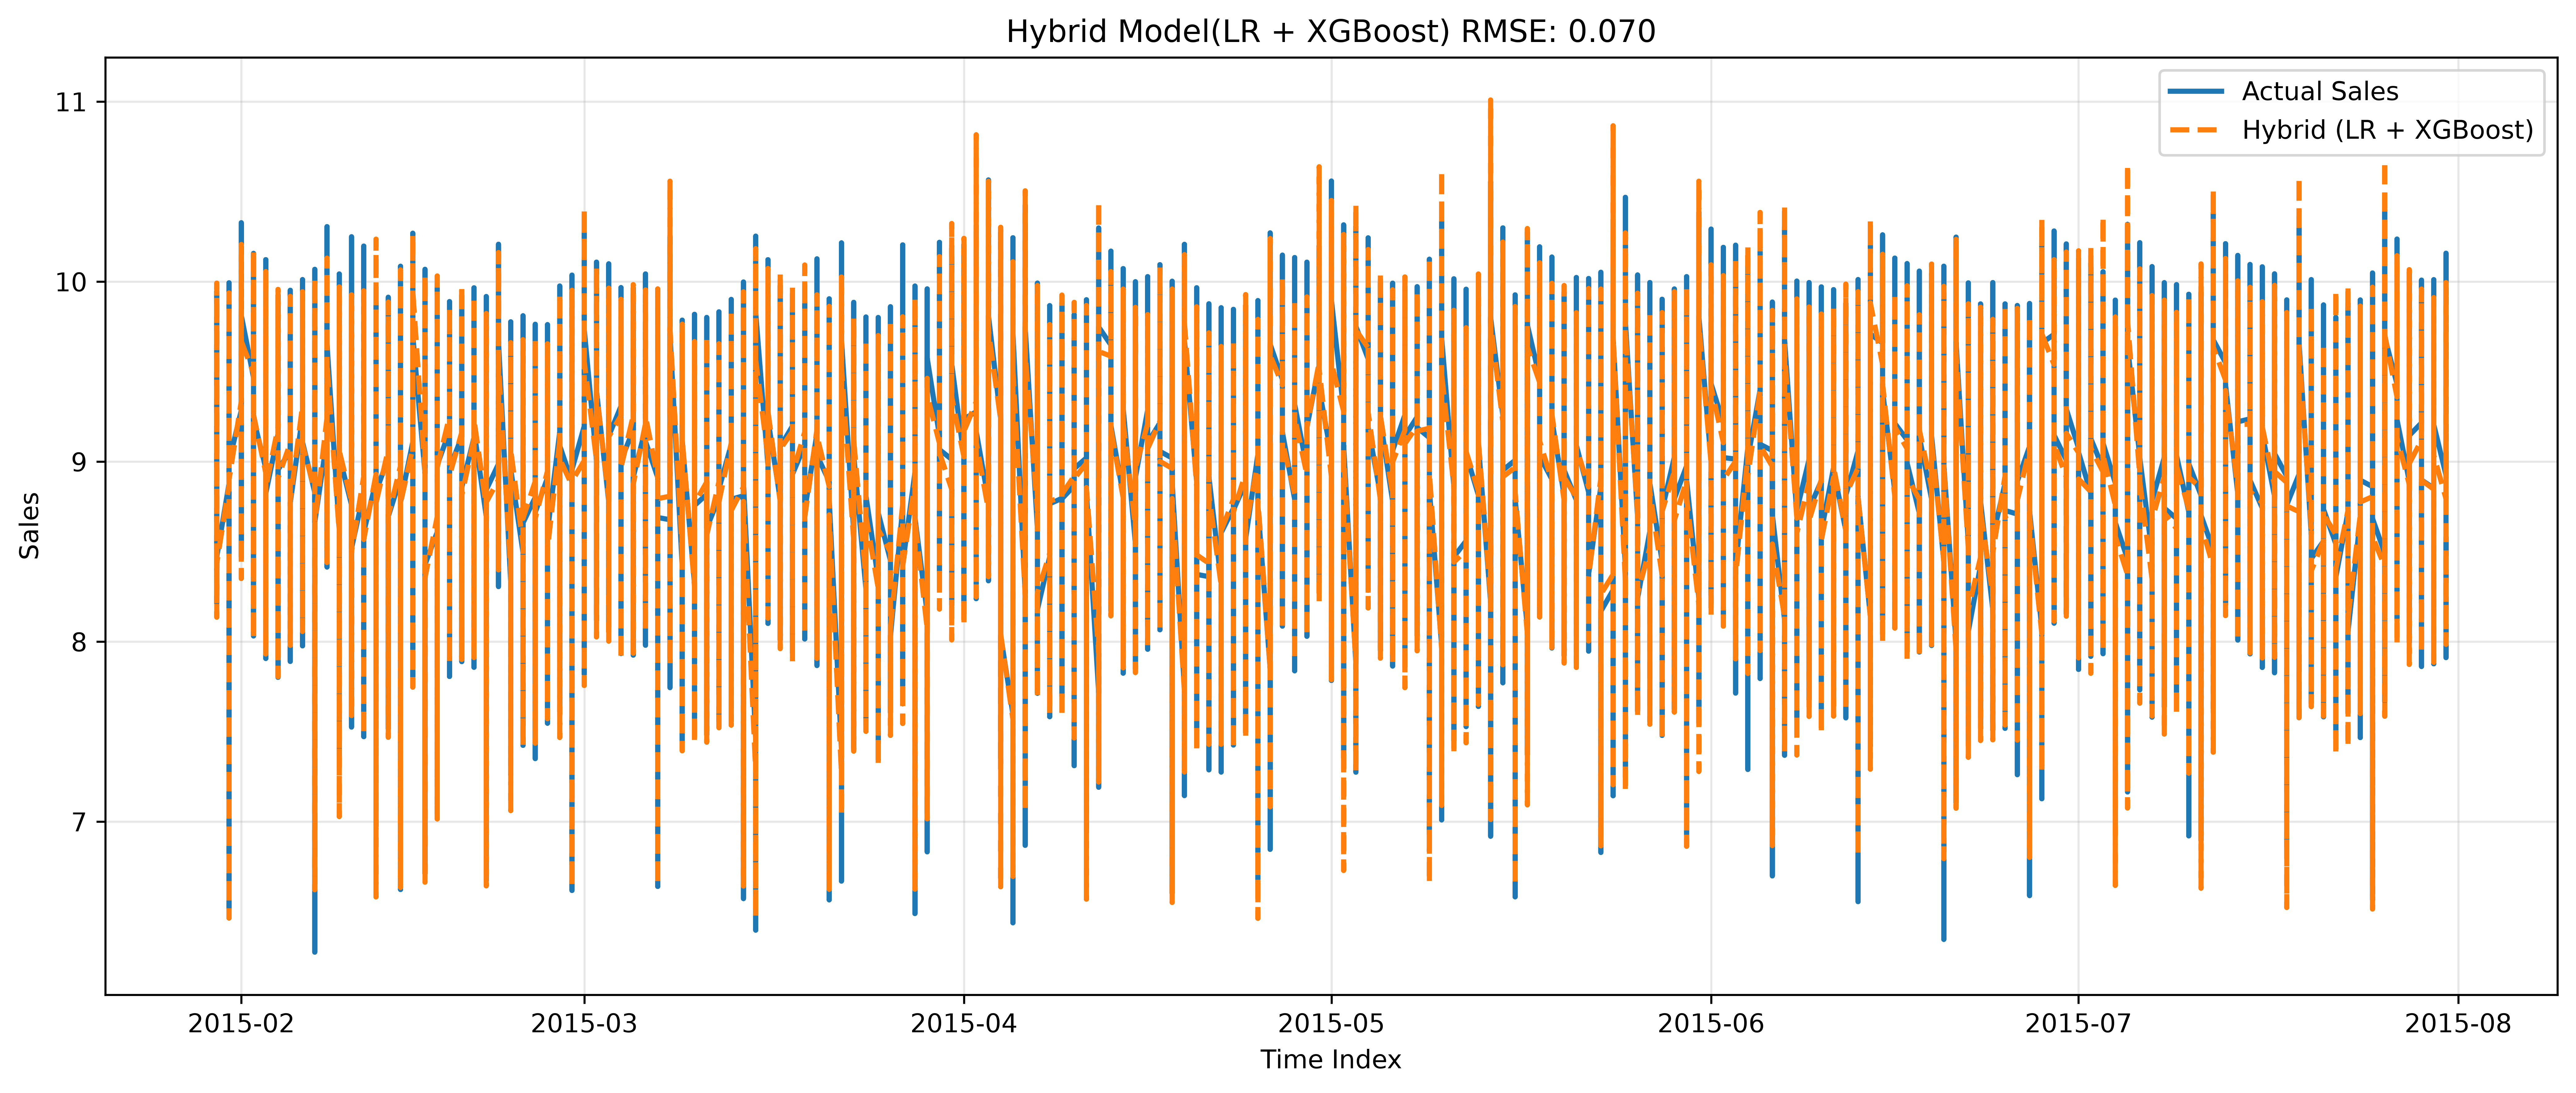

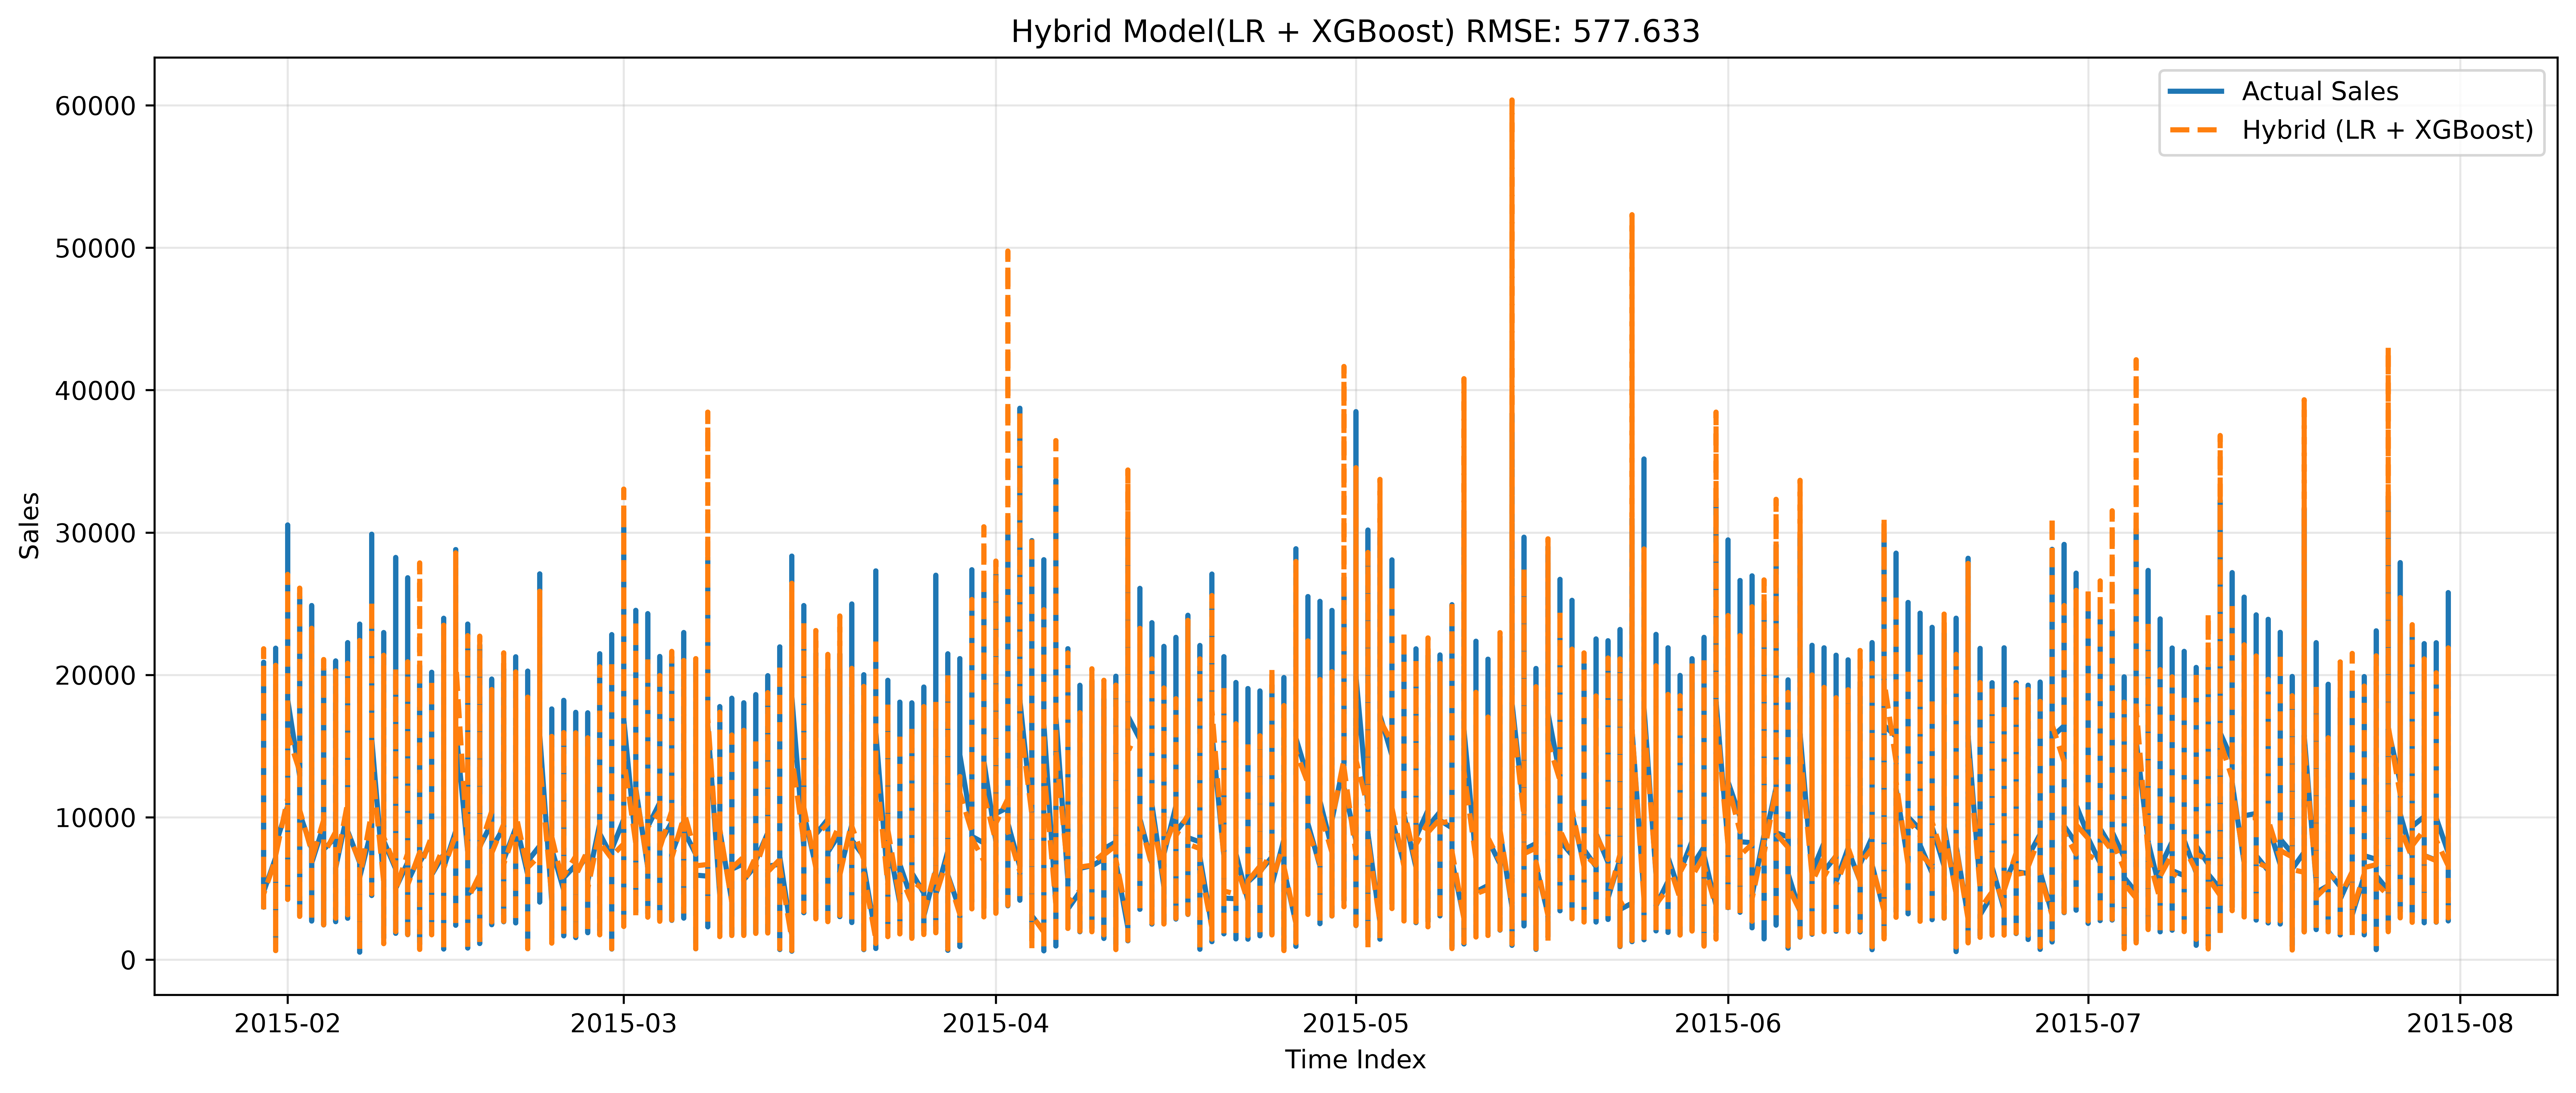

In [ ]:
# ===============================================================
# 9. VISUALISASI with Data Sales has Transformed
# ===============================================================
visualization_data = pd.DataFrame({
    'date': test.Date,
    'actual_sales': y_test_log.values,
    'pred_hybrid': hybrid_pred_log,
})

plt.figure(figsize=(14,6), dpi=600)
plt.plot(visualization_data['date'], visualization_data['actual_sales'], label='Actual Sales', linewidth=2)
plt.plot(visualization_data['date'], visualization_data['pred_hybrid'], label='Hybrid (LR + XGBoost)', linestyle='--', linewidth=2)
plt.title(f"Hybrid Model(LR + XGBoost) RMSE: {rmse_hybrid_log:.3f}")
plt.xlabel('Time Index')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ===============================================================
# 9. VISUALISASI with Original Sales
# ===============================================================
visualization_data = pd.DataFrame({
    'date': test.Date,
    'actual_sales': y_test_real.values,
    'pred_hybrid': hybrid_pred_real,
})

plt.figure(figsize=(14,6), dpi=600)
plt.plot(visualization_data['date'], visualization_data['actual_sales'], label='Actual Sales', linewidth=2)
plt.plot(visualization_data['date'], visualization_data['pred_hybrid'], label='Hybrid (LR + XGBoost)', linestyle='--', linewidth=2)
plt.title(f"Hybrid Model(LR + XGBoost) RMSE: {rmse_hybrid_real:.3f}")
plt.xlabel('Time Index')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Testing & Visualisasi (non-transformed sales)

#### Testing

In [ ]:
scaler = joblib.load('../src/utils/models/scaler.best.pkl')
lr_model = joblib.load('../src/utils/models/lr_model.best.pkl')
xgb_model = joblib.load('../src/utils/models/xgb_model.best.pkl')

display(xgb_model.get_params())

{'objective': 'reg:squarederror',
 'base_score': None,
 'booster': None,
 'callbacks': None,
 'colsample_bylevel': None,
 'colsample_bynode': None,
 'colsample_bytree': 1.0,
 'device': None,
 'early_stopping_rounds': None,
 'enable_categorical': False,
 'eval_metric': None,
 'feature_types': None,
 'feature_weights': None,
 'gamma': None,
 'grow_policy': None,
 'importance_type': None,
 'interaction_constraints': None,
 'learning_rate': 0.1,
 'max_bin': None,
 'max_cat_threshold': None,
 'max_cat_to_onehot': None,
 'max_delta_step': None,
 'max_depth': 7,
 'max_leaves': None,
 'min_child_weight': None,
 'missing': nan,
 'monotone_constraints': None,
 'multi_strategy': None,
 'n_estimators': 500,
 'n_jobs': None,
 'num_parallel_tree': None,
 'random_state': 42,
 'reg_alpha': None,
 'reg_lambda': None,
 'sampling_method': None,
 'scale_pos_weight': None,
 'subsample': 0.6,
 'tree_method': None,
 'validate_parameters': None,
 'verbosity': None}

In [ ]:
scaler = joblib.load('models/scaler.best.pkl')
lr_model = joblib.load('models/lr_model.best.pkl')
xgb_model = joblib.load('models/xgb_model.best.pkl')

# ===============================================================
# 3. SPLIT DATA TRAIN-TEST
# ===============================================================
total_data = len(series)
train_size = int(total_data * 0.8)

train = series[:train_size]
test = series[train_size:]

X_train = train.drop(columns=['Sales', 'Date'])
y_train = train['Sales']
X_test  = test.drop(columns=['Sales', 'Date'])
y_test  = test['Sales']

# ===============================================================
# 4. SCALING
# ===============================================================
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ===============================================================
# 4. TESTING
# ===============================================================

lr_pred = lr_model.predict(X_test_scaled)

xgb_pred = xgb_model.predict(X_test_scaled)
hybrid_pred = lr_pred + xgb_pred

# ===============================================================
# 8. EVALUATION
# ===============================================================
mse_hybrid = mean_squared_error(y_test, hybrid_pred)
rmse_hybrid = np.sqrt(mse_hybrid)

print(f"RMSE Hybrid Log Scale: {rmse_hybrid:.3f}")

RMSE Hybrid Log Scale: 661.599


#### Visualization

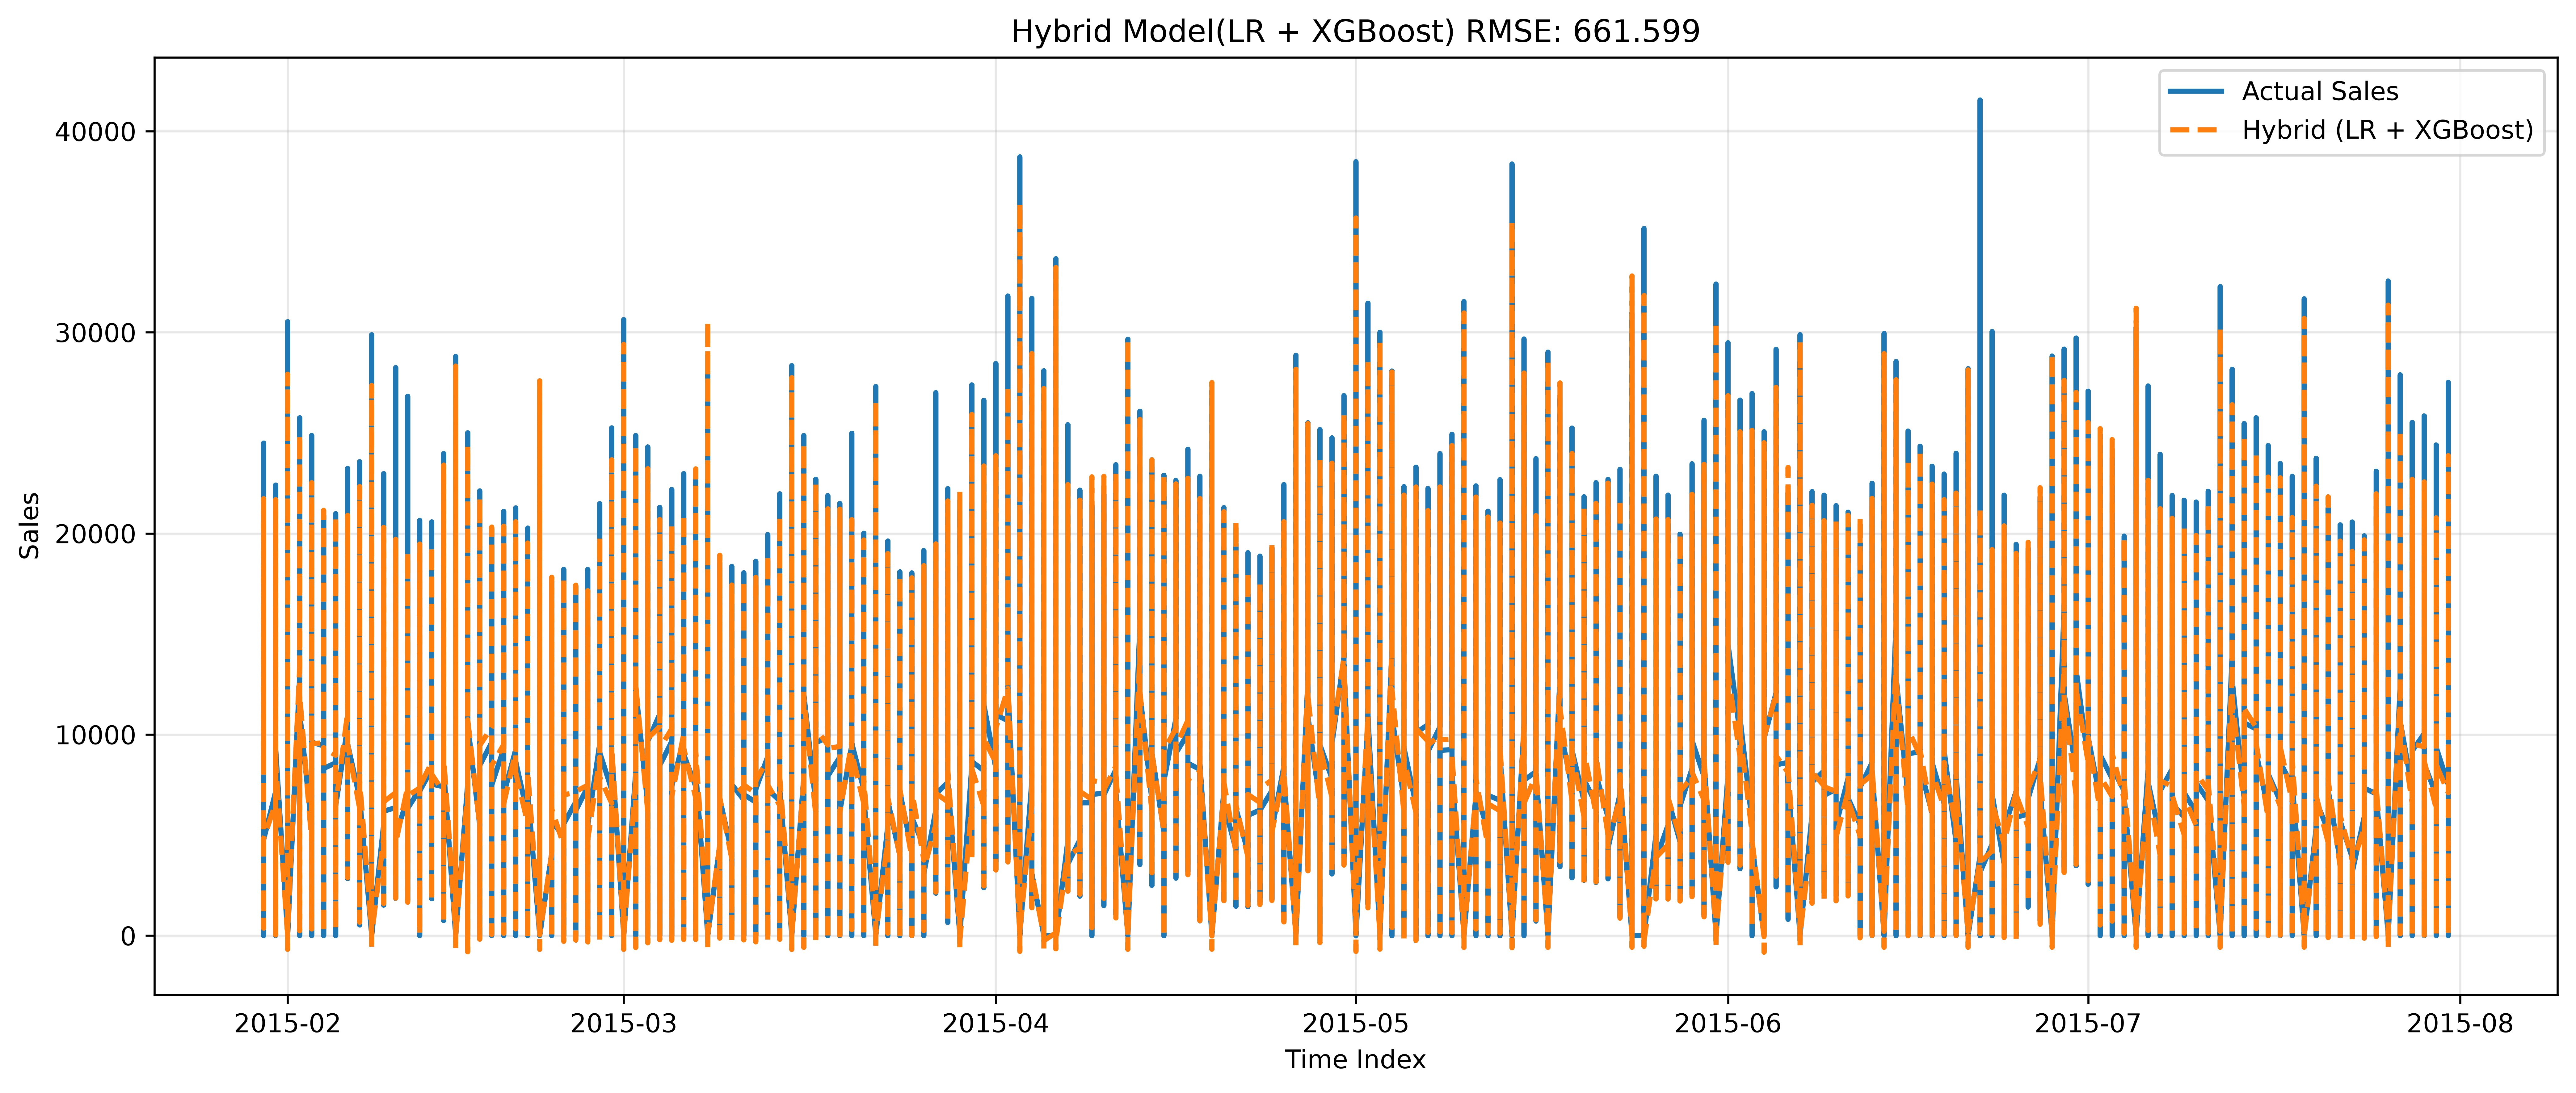

In [ ]:
# ===============================================================
# 9. VISUALISASI
# ===============================================================
visualization_data = pd.DataFrame({
    'date': test.Date,
    'actual_sales': y_test.values,
    'pred_hybrid': hybrid_pred,
})

plt.figure(figsize=(14,6), dpi=600)
plt.plot(visualization_data['date'], visualization_data['actual_sales'], label='Actual Sales', linewidth=2)
plt.plot(visualization_data['date'], visualization_data['pred_hybrid'], label='Hybrid (LR + XGBoost)', linestyle='--', linewidth=2)
plt.title(f"Hybrid Model(LR + XGBoost) RMSE: {rmse_hybrid:.3f}")
plt.xlabel('Time Index')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()